<u>References:</u><br>
(1) He, K., Zhang, X., Ren, S. & Sun, J. (2016). Deep Residual Learning for Image Recognition. CVPR. <br>
(2) https://medium.com/@deepvisionkararhaider/resnet-50-explained-step-by-step-the-easiest-guide-to-deep-residual-networks-7616f4f45046 <br>
(3) https://medium.com/@lucrece.shin/chapter-3-transfer-learning-with-resnet50-from-dataloaders-to-training-seed-of-thought-67aaf83155bc <br>

In [3]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc, roc_auc_score, RocCurveDisplay, \
accuracy_score, balanced_accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from itertools import cycle

import torch
from torch import optim
from torch import nn
from torch.utils.data import DataLoader
import torchvision
import torch.nn.functional as F
import torchvision.datasets as datasets
import torchvision.transforms as transforms
import torchvision.models as models
from torchsummary import summary

In [5]:
input_fpath = '/content/drive/MyDrive/chest_xray_resized_new_3'
output_fpath = '/content/drive/MyDrive/model_output'

In [6]:
def target_transform(x):
    return x

def load_datasets(train_path, val_path, test_path):
    imagenet_mean = [0.485, 0.456, 0.406]
    imagenet_std = [0.229, 0.224, 0.225]
    # Pre-trained models expect inputs normalized to a specific range. Matching the normalization ensures consistency and better transfer learning performance.
    val_img_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])  # by default, transforms.ToTensor() will output 3 channels (make 3 identical copies of the original grayscale channel). VGG16 model which requires 3 channels
    train_img_transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize(mean=imagenet_mean, std=imagenet_std)])
    train_dataset = datasets.ImageFolder(train_path, transform=train_img_transform, target_transform = target_transform)
    val_dataset = datasets.ImageFolder(val_path, transform=val_img_transform, target_transform = target_transform)
    test_dataset = datasets.ImageFolder(test_path, transform=val_img_transform, target_transform = target_transform)
    print(f"Train set size: {len(train_dataset)}, Validation set size: {len(val_dataset)}, Test set size: {len(test_dataset)}")
    return train_dataset, val_dataset, test_dataset

In [7]:
# load all datasets
train_set, val_set, test_set = load_datasets(input_fpath + "/train", input_fpath + "/val", input_fpath + "/test")

Train set size: 4184, Validation set size: 1048, Test set size: 624


In [8]:
# response variable class labels
print(train_set.class_to_idx)
print(val_set.class_to_idx)
print(test_set.class_to_idx)

{'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}
{'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}
{'BACTERIA': 0, 'NORMAL': 1, 'VIRUS': 2}


In [9]:
def construct_dataloaders(train_set, val_set, test_set, batch_size, shuffle=True):
    train_dataloader = torch.utils.data.DataLoader(train_set, batch_size, shuffle)
    val_dataloader = torch.utils.data.DataLoader(val_set, batch_size)
    test_dataloader = torch.utils.data.DataLoader(test_set, batch_size)
    return train_dataloader, val_dataloader, test_dataloader

In [10]:
# specify data loaders for CNN workflow
batch_size = 60
train_dataloader, val_dataloader, test_dataloader = construct_dataloaders(train_set, val_set, test_set, batch_size, True)

In [11]:
# device for running CNN model (GPU or CPU)
device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [12]:
# Load pre-trained ResNet50 model
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

# Freeze all backbone parameters (weights) of the ResNet50 model
for param in model.parameters():
    param.requires_grad = False

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 285MB/s]


In [13]:
# Replace the output layer of the ResNet50 model (the original model has 1000 out_features)
model.fc = nn.Sequential(
    nn.Linear(model.fc.in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(256, 3)  # for 3-class classification, out_features = 3
)

if device == "cuda":
    model = model.cuda()
summary(model, input_size=(3, 224, 224),device=device)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [14]:
# Verify trainable vs. frozen parameters
total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
frozen_params    = total_params - trainable_params
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}  ({trainable_params/total_params*100:.2f}%)")
print(f"Frozen parameters:    {frozen_params:,}  ({frozen_params/total_params*100:.2f}%)")

Total parameters:     24,033,347
Trainable parameters: 525,315  (2.19%)
Frozen parameters:    23,508,032  (97.81%)


In [15]:
# Define the loss function
criterion = nn.CrossEntropyLoss() # suitable for classification tasks

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0005)

In [16]:
class EarlyStopping:

    def __init__(self, patience=5, delta=0.01, path=output_fpath + '/checkpoint_resnet50_3_classes.pt', verbose=True):
        '''
        An early stopping mechanism prevents CNN from overfitting the training data by monitering the change of the loss function on the validation set
        after each training epoch.
        '''
        self.patience = patience # how long to wait after the last best improvement before stopping
        self.delta = delta # the minimum change in validation loss that we care about
        self.path = path
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0

    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
            # Save checkpoint if improvement observed
            torch.save(model.state_dict(), self.path)
            if self.verbose:
                print(f"Model improved; checkpoint saved at loss {val_loss:.4f}")
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                print("Early stopping triggered.")
                return True  # Signal to stop training
        return False

In [17]:
# Instantiate an early stopping controller
early_stopping = EarlyStopping(patience=5, delta=0.01)

In [18]:
# Training loop with early stopping and checkpointing
num_epochs = 100
train_losses, val_losses = [], []

for epoch in range(num_epochs):
    # training within each epoch
    model.train() # Set model to training mode
    train_loss = 0.0
    print("Epoch {} Training...".format(epoch))
    for batch_indx, (data, target) in enumerate(train_dataloader):
        print("Batch", batch_indx)
        if device == "cuda":
            data = data.cuda()
            target = target.cuda()
        optimizer.zero_grad() # Reset parameter gradients to zero
        output = model(data) # Forward pass
        loss = criterion(output, target) # Compute the loss function for the batch
        loss.backward() # Back propogation
        optimizer.step() # Update weights
        train_loss += loss.item()
    train_losses.append(train_loss / len(train_dataloader)) # Loss function averaged over all batches

    # using validation set to monitor the model performance after each training epoch
    model.eval() # Set model to evaluation mode
    val_loss = 0.0
    print("Epoch {} Evaluation...".format(epoch))
    with torch.no_grad(): # This method disables the gradient calculation which reduces the memory consumption for computations
        for data, target in val_dataloader:
            if device == "cuda":
                data = data.cuda()
                target = target.cuda()
            output = model(data) # Forward pass
            loss = criterion(output, target) # Compute the loss function for the batch
            val_loss += loss.item()
    val_loss /= len(val_dataloader)
    val_losses.append(val_loss) # Loss function averaged over all batches

    # Early stopping check
    if early_stopping.check_early_stop(val_loss):
        print(f"Stopping training at epoch {epoch+1}")
        break

Epoch 0 Training...
Batch 0
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
Batch 31
Batch 32
Batch 33
Batch 34
Batch 35
Batch 36
Batch 37
Batch 38
Batch 39
Batch 40
Batch 41
Batch 42
Batch 43
Batch 44
Batch 45
Batch 46
Batch 47
Batch 48
Batch 49
Batch 50
Batch 51
Batch 52
Batch 53
Batch 54
Batch 55
Batch 56
Batch 57
Batch 58
Batch 59
Batch 60
Batch 61
Batch 62
Batch 63
Batch 64
Batch 65
Batch 66
Batch 67
Batch 68
Batch 69
Epoch 0 Evaluation...
Model improved; checkpoint saved at loss 0.6114
Epoch 1 Training...
Batch 0
Batch 1
Batch 2
Batch 3
Batch 4
Batch 5
Batch 6
Batch 7
Batch 8
Batch 9
Batch 10
Batch 11
Batch 12
Batch 13
Batch 14
Batch 15
Batch 16
Batch 17
Batch 18
Batch 19
Batch 20
Batch 21
Batch 22
Batch 23
Batch 24
Batch 25
Batch 26
Batch 27
Batch 28
Batch 29
Batch 30
B

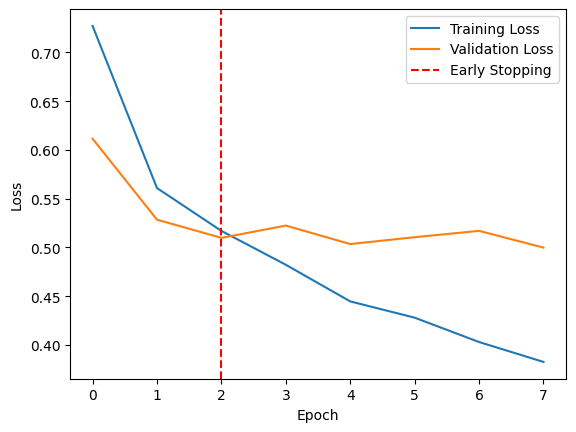

In [19]:
# Load best model checkpoint after early stopping
model.load_state_dict(torch.load(early_stopping.path))

# Final loss vs. epoch plot for both training and validation sets
epoch_list = np.arange(0, len(val_losses))
plt.plot(epoch_list, train_losses, label="Training Loss")
plt.plot(epoch_list, val_losses, label="Validation Loss")
plt.axvline(x=len(val_losses)-early_stopping.no_improvement_count-1, color='r', linestyle='--', label="Early Stopping")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [20]:
# Iterate over the test set batches to generate predicted probabilities for all 3 classes
model.eval() # Set model to evaluation mode
preds_list = []
y_list = []
with torch.no_grad(): # disabling the gradient calculation when evaluating model performance on test set
   for images, labels in test_dataloader:
       if device == "cuda":
           images = images.cuda()
           labels = labels.cuda()
       # Get predicted probabilities for test data batch
       outputs = model(images)
       # Convert the raw values in the output neurons to predicted probabilities:
       # dim is the dimension along which softmax will be computed. In this case, dim = 0 corresponds to indices for observations in the batch, dim = 1 corresponds to the raw output values of each observation
       preds = F.softmax(outputs, dim=1)
       preds_list.append(preds)
       y_list.append(labels)
if device == "cuda":
    pred_probabilities = torch.cat(preds_list, dim = 0).cpu().numpy() # n_test x 3
    actual_y = torch.cat(y_list, dim = 0).cpu().numpy()
else:
    pred_probabilities = torch.cat(preds_list, dim = 0).numpy() # n_test x 3
    actual_y = torch.cat(y_list, dim = 0).numpy()

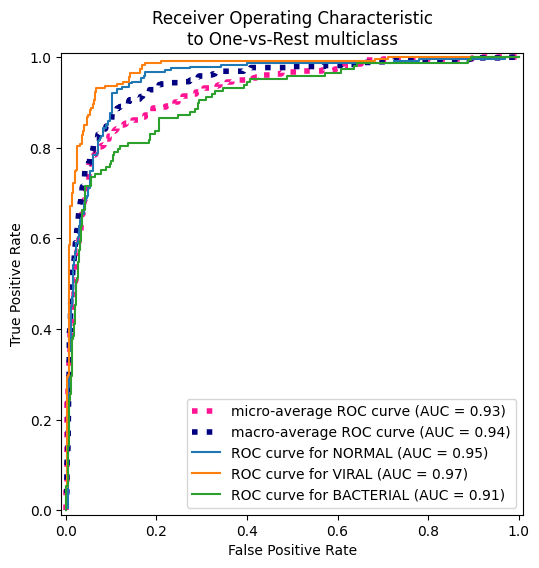

In [21]:
# One vs. Rest ROC/AUC on the test set
y_onehot_test = LabelBinarizer().fit_transform(actual_y)
fpr, tpr, roc_auc = dict(), dict(), dict()
fpr["micro"], tpr["micro"], _ = roc_curve(y_onehot_test.ravel(), pred_probabilities.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
target_names = {0:'NORMAL', 1:'VIRAL', 2:'BACTERIAL'}
n_classes = len(target_names)
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_onehot_test[:, i], pred_probabilities[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
fpr_grid = np.linspace(0.0, 1.0, 1000)
mean_tpr = np.zeros_like(fpr_grid) # Interpolate all ROC curves at these points
for i in range(n_classes):
    mean_tpr += np.interp(fpr_grid, fpr[i], tpr[i])  # linear interpolation
mean_tpr /= n_classes
fpr["macro"] = fpr_grid
tpr["macro"] = mean_tpr
roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

fig, ax = plt.subplots(figsize=(6, 6))
plt.plot(
    fpr["micro"],
    tpr["micro"],
    label=f"micro-average ROC curve (AUC = {roc_auc['micro']:.2f})",
    color="deeppink",
    linestyle=":",
    linewidth=4,
)
plt.plot(
    fpr["macro"],
    tpr["macro"],
    label=f"macro-average ROC curve (AUC = {roc_auc['macro']:.2f})",
    color="navy",
    linestyle=":",
    linewidth=4,
)
colors = cycle(["aqua", "darkorange", "cornflowerblue"])
for class_id, color in zip(range(n_classes), colors):
    RocCurveDisplay.from_predictions(
        y_onehot_test[:, class_id],
        pred_probabilities[:, class_id],
        name=f"ROC curve for {target_names[class_id]}",
        ax=ax,
    )
_ = ax.set(
    xlabel="False Positive Rate",
    ylabel="True Positive Rate",
    title="Receiver Operating Characteristic\nto One-vs-Rest multiclass",
)

Accuracy = 0.8221
Balanced accuracy = 0.811
One vs. Rest Evaluation Metrics:
       class precision recall    f1    n
0     NORMAL      0.96   0.74  0.83  234
1      VIRAL      0.73   0.74  0.74  148
2  BACTERIAL      0.79   0.95  0.86  242
Confusion matrix:


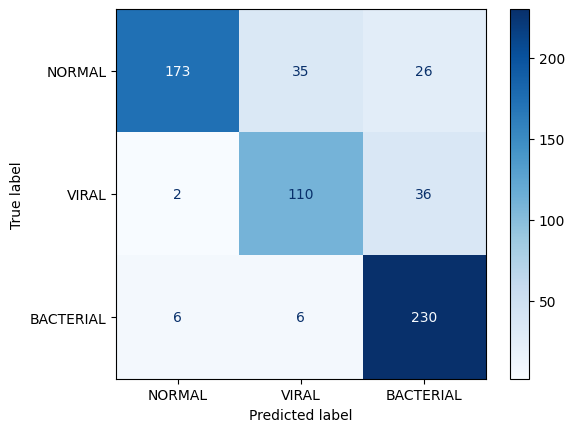

In [22]:
# Other evaluation metrics on the test set (overall and one vs. rest)
pred_y = np.argmax(pred_probabilities, 1)
print("Accuracy =", round(accuracy_score(actual_y, pred_y),4))
print("Balanced accuracy =", round(balanced_accuracy_score(actual_y, pred_y),4))
cr = classification_report(actual_y, pred_y, target_names=['BACTERIAL', 'NORMAL', 'VIRAL']).split("\n")
cr = [r for r in cr if r != ''][1:4]
cr = [tuple([e for e in r.split(" ") if e != ""]) for r in cr]
cr = [cr[i] for i in [1,2,0]]
print("One vs. Rest Evaluation Metrics:")
print(pd.DataFrame(cr, columns = ['class', 'precision', 'recall', 'f1', 'n']))
print("Confusion matrix:")
cm = confusion_matrix(actual_y, pred_y, labels=[1,2,0])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NORMAL', 'VIRAL', 'BACTERIAL'])
disp.plot(cmap=plt.cm.Blues)
plt.show()

In [23]:
# class MyDataset(Dataset):
#     def __getitem__(self, index):
#         data, target = self.data[index], self.targets[index]
#         # Explicitly return the index along with data
#         return data, target, index

# # Usage in training loop
# for batch_idx, (data, target, sample_indices) in enumerate(dataloader):
#     print(f"Indices in this batch: {sample_indices}")